# Respondent Similarity Network

Family 1: **nodes = respondents, edges = pairwise opinion similarity** across all 60
Likert statements (Pearson correlation, thresholded into a graph). This is the
network-science core of the assignment. See `Statement_Bipartite_Network.ipynb` for
the complementary bipartite/statement-projection family.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from networkx.algorithms.community import louvain_communities

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

## 1. Load and encode the data

In [2]:
df = pd.read_csv("Survey_Results_UC.csv", encoding="utf-8-sig")
df = df.rename(columns={"id. Response ID": "respondent_id"})
df = df.set_index("respondent_id")

category_map = {col: col[0] for col in df.columns}
category_names = {"T": "Technology", "E": "Education", "S": "Ethics/Society", "V": "Environment"}
categories = pd.Series(category_map)

likert_map = {"Strongly Disagree": -2, "Disagree": -1, "Neutral": 0, "Agree": 1, "Strongly Agree": 2}
df_num = df.replace({"": np.nan, "No Comments": np.nan}).replace(likert_map).apply(pd.to_numeric)

print(f"Respondents: {df_num.shape[0]}, Statements: {df_num.shape[1]}")
print(f"NaN cells after encoding: {df_num.isna().values.sum()} ({df_num.isna().values.mean():.2%})")

Respondents: 96, Statements: 60
NaN cells after encoding: 542 (9.41%)


In [3]:
# Per-respondent mean score in each category — used later to interpret detected communities
category_scores = pd.DataFrame({
    cat_letter: df_num.loc[:, categories == cat_letter].mean(axis=1)
    for cat_letter in category_names
}).rename(columns=category_names)
category_scores.head()

,Technology,Education,Ethics/Society,Environment
respondent_id,,,,
11,0.800000,0.800000,0.933333,0.533333
12,0.533333,0.933333,0.571429,0.800000
13,0.933333,1.066667,1.333333,1.666667
14,0.800000,0.600000,1.133333,1.200000
16,1.200000,0.666667,1.266667,1.266667


## 2. Pairwise respondent similarity

Pearson correlation between each pair of respondents' 60-dimensional answer vectors
(pairwise-complete). This is the edge weight the network is built from.

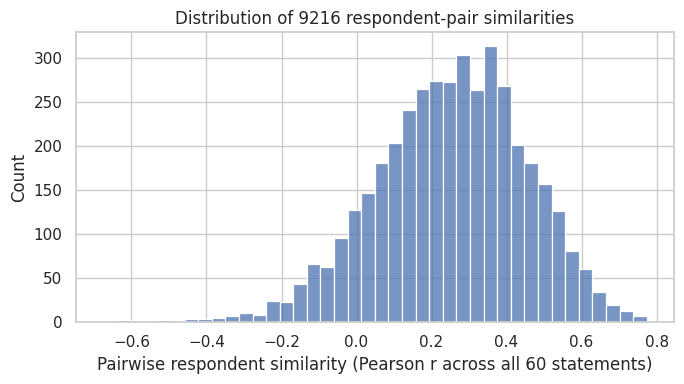

count    4091.000000
mean        0.252102
std         0.200170
min        -0.676084
25%         0.121913
50%         0.263331
75%         0.393101
max         0.773922
dtype: float64

In [4]:
respondent_sim = df_num.T.corr()  # 96x96

sim_values = respondent_sim.where(np.triu(np.ones(respondent_sim.shape), k=1).astype(bool)).stack()

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(sim_values, bins=40, ax=ax)
ax.set_xlabel("Pairwise respondent similarity (Pearson r across all 60 statements)")
ax.set_title(f"Distribution of {len(sim_values)} respondent-pair similarities")
plt.tight_layout()
plt.show()

sim_values.describe()

## 3. Build the network

Keep edges above a similarity threshold — a common way to turn a dense similarity
matrix into a sparse graph (a correlation "backbone").

In [5]:
RESP_THRESHOLD = 0.4

G_resp = nx.Graph()
G_resp.add_nodes_from(df_num.index)
for i, a in enumerate(df_num.index):
    for b in df_num.index[i + 1:]:
        r = respondent_sim.loc[a, b]
        if pd.notna(r) and r >= RESP_THRESHOLD:
            G_resp.add_edge(a, b, weight=r)

n, m = G_resp.number_of_nodes(), G_resp.number_of_edges()
print(f"Respondent network: {n} nodes, {m} edges (threshold r >= {RESP_THRESHOLD})")
print(f"Density: {nx.density(G_resp):.3f}")
print(f"Average degree: {2 * m / n:.2f}")
print(f"Isolated nodes (degree 0): {sum(1 for _, d in G_resp.degree() if d == 0)}")

components = sorted(nx.connected_components(G_resp), key=len, reverse=True)
print(f"Connected components: {len(components)}, largest has {len(components[0])} nodes")
print(f"Average clustering coefficient: {nx.average_clustering(G_resp):.3f}")

Respondent network: 96 nodes, 957 edges (threshold r >= 0.4)
Density: 0.210
Average degree: 19.94
Isolated nodes (degree 0): 8
Connected components: 9, largest has 88 nodes
Average clustering coefficient: 0.510


### 3.1 Threshold sensitivity

The threshold is an arbitrary choice that needs justifying. Sweep it and look at edge
count / giant-component size, like a percolation curve, to pick one that yields a
connected-but-sparse graph.

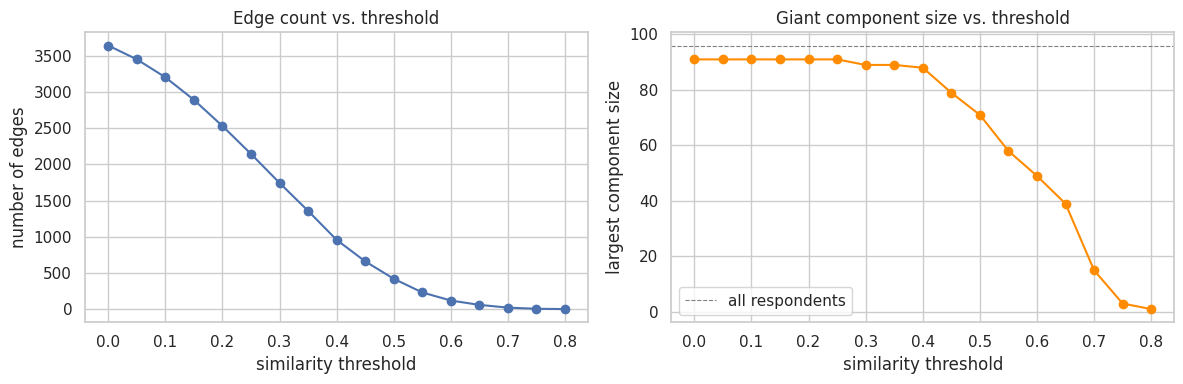

In [6]:
thresholds = np.arange(0.0, 0.81, 0.05)
sweep = []
sim_no_diag = respondent_sim.where(~np.eye(len(respondent_sim), dtype=bool))

for t in thresholds:
    edges = (sim_no_diag >= t).values.sum() // 2
    Gt = nx.Graph()
    Gt.add_nodes_from(df_num.index)
    Gt.add_edges_from(
        (a, b) for a in df_num.index for b in df_num.index
        if a < b and pd.notna(sim_no_diag.loc[a, b]) and sim_no_diag.loc[a, b] >= t
    )
    giant = len(max(nx.connected_components(Gt), key=len))
    sweep.append({"threshold": t, "edges": edges, "density": nx.density(Gt), "giant_component": giant})

sweep_df = pd.DataFrame(sweep)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sweep_df["threshold"], sweep_df["edges"], marker="o")
axes[0].set_xlabel("similarity threshold"); axes[0].set_ylabel("number of edges")
axes[0].set_title("Edge count vs. threshold")

axes[1].plot(sweep_df["threshold"], sweep_df["giant_component"], marker="o", color="darkorange")
axes[1].axhline(df_num.shape[0], color="gray", linestyle="--", linewidth=0.8, label="all respondents")
axes[1].set_xlabel("similarity threshold"); axes[1].set_ylabel("largest component size")
axes[1].set_title("Giant component size vs. threshold")
axes[1].legend()
plt.tight_layout()
plt.show()

### 3.2 Degree distribution

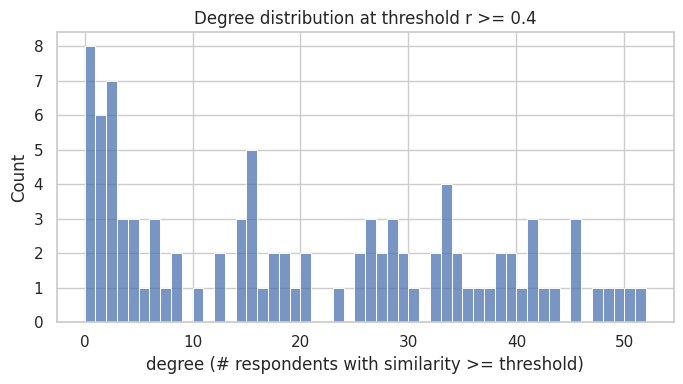

Highest-degree respondents (most 'typical'/consensus opinions at this threshold):


49     51
61     50
114    49
70     48
67     47
Name: degree, dtype: int64

In [7]:
degrees = pd.Series(dict(G_resp.degree()), name="degree")

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(degrees, bins=range(0, degrees.max() + 2), ax=ax)
ax.set_xlabel("degree (# respondents with similarity >= threshold)")
ax.set_title(f"Degree distribution at threshold r >= {RESP_THRESHOLD}")
plt.tight_layout()
plt.show()

print("Highest-degree respondents (most 'typical'/consensus opinions at this threshold):")
degrees.sort_values(ascending=False).head(5)

### 3.3 Centrality

Degree, betweenness, eigenvector centrality on the giant component (centrality is
ill-defined for betweenness/eigenvector on a disconnected graph).

In [8]:
G_giant = G_resp.subgraph(components[0]).copy()

centrality = pd.DataFrame({
    "degree": nx.degree_centrality(G_giant),
    "betweenness": nx.betweenness_centrality(G_giant, weight="weight"),
    "eigenvector": nx.eigenvector_centrality(G_giant, weight="weight", max_iter=1000),
})

print(f"Centrality computed on the giant component ({G_giant.number_of_nodes()} nodes)")
centrality.sort_values("eigenvector", ascending=False).head(10)

Centrality computed on the giant component (88 nodes)


,degree,betweenness,eigenvector
114,0.563218,0.018712,0.208442
49,0.586207,0.063619,0.205486
61,0.574713,0.018177,0.204991
81,0.471264,0.001069,0.189171
104,0.517241,0.006950,0.188665
90,0.517241,0.035819,0.187521
67,0.540230,0.017642,0.186763
70,0.551724,0.045175,0.184908
55,0.517241,0.017910,0.181765
83,0.471264,0.008019,0.176003


### 3.4 Community detection

Louvain communities, cross-checked against mean category scores (is a community just
"people who like Technology", or a broader ideological alignment across all four
categories?).

In [9]:
resp_communities = louvain_communities(G_resp, weight="weight", seed=0)
resp_community_of = {n: i for i, comm in enumerate(resp_communities) for n in comm}
print(f"Detected {len(resp_communities)} communities (sizes: {sorted((len(c) for c in resp_communities), reverse=True)})")

comm_series = pd.Series(resp_community_of, name="community")
print("\nMean category score by detected community:")
category_scores.join(comm_series).groupby("community")[list(category_names.values())].mean()

Detected 12 communities (sizes: [31, 24, 22, 11, 1, 1, 1, 1, 1, 1, 1, 1])

Mean category score by detected community:


,Technology,Education,Ethics/Society,Environment
community,,,,
0,0.933333,1.024176,1.425000,1.426984
1,NaN,NaN,NaN,NaN
2,1.156494,0.751701,1.322519,1.421429
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,0.869467,0.988462,1.248980,1.352381
8,1.266667,0.921212,1.248918,1.587879


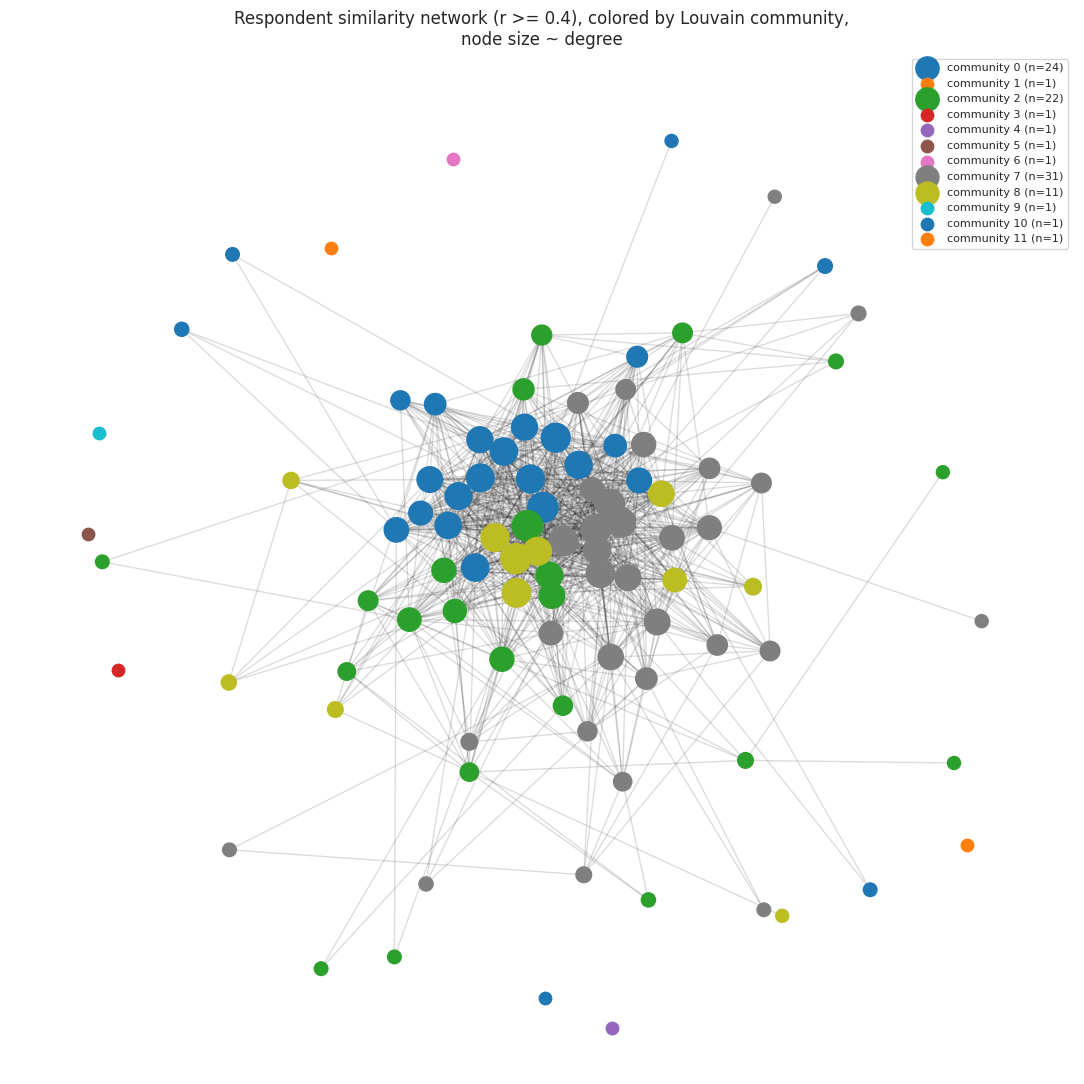

In [10]:
pos_resp = nx.spring_layout(G_resp, weight="weight", seed=0, k=0.6)
comm_palette = sns.color_palette("tab10", len(resp_communities))

fig, ax = plt.subplots(figsize=(11, 11))
nx.draw_networkx_edges(G_resp, pos_resp, alpha=0.15, ax=ax)
for i, comm in enumerate(resp_communities):
    sizes = [80 + 400 * degrees.get(node, 0) / max(degrees.max(), 1) for node in comm]
    nx.draw_networkx_nodes(G_resp, pos_resp, nodelist=list(comm), node_color=[comm_palette[i]],
                            node_size=sizes, label=f"community {i} (n={len(comm)})", ax=ax)
ax.set_title(f"Respondent similarity network (r >= {RESP_THRESHOLD}), colored by Louvain community,\n"
             "node size ~ degree")
ax.legend(scatterpoints=1, fontsize=8)
ax.axis("off")
plt.tight_layout()
plt.show()

### 3.5 Where do the flagged "trivial" respondents end up?

IDs 41, 90, 91, 94, 110 were flagged as potentially straight-lined in
`Response_Quality_Check.ipynb` but kept in (per team decision). Near-zero variance
means their correlation with others is undefined/near-zero, so they should show up
low-degree/near-isolated here rather than distorting the network.

In [11]:
flagged_ids = [41, 90, 91, 94, 110]
print(f"Median degree overall: {degrees.median():.1f}")
degrees.loc[degrees.index.isin(flagged_ids)].rename("degree").to_frame().assign(
    percentile=lambda d: d["degree"].apply(lambda v: (degrees <= v).mean())
)

Median degree overall: 17.5


,degree,percentile
41,26,0.614583
90,45,0.947917
91,18,0.520833
94,28,0.666667
110,34,0.781250


## 4. How robust are the Louvain communities?

Louvain is a greedy heuristic: it optimizes modularity, not "distance between
communities," and its output can depend on the RNG seed (tie-breaking) and on the
similarity threshold used to build the graph in the first place. Before treating
communities 0-3 as real opinion camps, check whether they survive changing either.

### 4.1 Seed sensitivity (same graph, different Louvain runs)

In [12]:
from sklearn.metrics import adjusted_rand_score
from itertools import combinations

SEEDS = range(10)
partitions = {}
for s in SEEDS:
    comms = louvain_communities(G_resp, weight="weight", seed=s)
    partitions[s] = {n: i for i, comm in enumerate(comms) for n in comm}

n_communities = {s: len(set(p.values())) for s, p in partitions.items()}
print("Number of communities detected per seed:", n_communities)

pairwise_ari = [
    adjusted_rand_score([partitions[s1][n] for n in G_resp.nodes],
                         [partitions[s2][n] for n in G_resp.nodes])
    for s1, s2 in combinations(SEEDS, 2)
]
print(f"\nPairwise ARI across {len(SEEDS)} seeds: mean={pd.Series(pairwise_ari).mean():.3f}, "
      f"min={min(pairwise_ari):.3f}, max={max(pairwise_ari):.3f}")

Number of communities detected per seed: {0: 12, 1: 11, 2: 12, 3: 12, 4: 12, 5: 12, 6: 12, 7: 12, 8: 12, 9: 12}

Pairwise ARI across 10 seeds: mean=0.662, min=0.449, max=1.000


### 4.2 Threshold sensitivity (community-level)

Section 3.1 already showed how edge count / giant component size respond to the
threshold. Here we check the community *labels* specifically: rebuild the network at
nearby thresholds and compare each partition to the baseline (r >= 0.4) via ARI.

In [13]:
BASELINE_THRESHOLD = 0.4
test_thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

threshold_partitions = {}
for t in test_thresholds:
    Gt = nx.Graph()
    Gt.add_nodes_from(df_num.index)
    for i, a in enumerate(df_num.index):
        for b in df_num.index[i + 1:]:
            r = respondent_sim.loc[a, b]
            if pd.notna(r) and r >= t:
                Gt.add_edge(a, b, weight=r)
    comms = louvain_communities(Gt, weight="weight", seed=0)
    threshold_partitions[t] = {n: i for i, comm in enumerate(comms) for n in comm}

baseline = threshold_partitions[BASELINE_THRESHOLD]
print(f"ARI of each threshold's partition vs. the baseline (r >= {BASELINE_THRESHOLD}):")
for t in test_thresholds:
    ari = adjusted_rand_score([baseline[n] for n in df_num.index],
                               [threshold_partitions[t][n] for n in df_num.index])
    n_comms = len(set(threshold_partitions[t].values()))
    print(f"  r >= {t:.2f}: {n_comms} communities, ARI={ari:.3f}")

ARI of each threshold's partition vs. the baseline (r >= 0.4):
  r >= 0.30: 10 communities, ARI=0.458
  r >= 0.35: 11 communities, ARI=0.482
  r >= 0.40: 12 communities, ARI=1.000
  r >= 0.45: 24 communities, ARI=0.371
  r >= 0.50: 29 communities, ARI=0.356


## 5. Pairwise belief-profile distinctness between all four communities

Extending the community-0-vs-3 comparison to every pair of the four substantial
communities: cross- vs. within-community mean similarity (in the same Pearson-r terms
the network was built from), cosine similarity of mean belief vectors, and how many of
the 60 statements show a statistically significant / large-effect-size difference.

In [14]:
from scipy.stats import ttest_ind

main_communities = {i: list(comm) for i, comm in enumerate(sorted(
    [c for c in louvain_communities(G_resp, weight='weight', seed=0) if len(c) >= 10],
    key=len, reverse=True))}
print("Communities used:", {i: len(m) for i, m in main_communities.items()})

def mean_r(group_a, group_b=None):
    if group_b is None:
        vals = [respondent_sim.loc[a, b] for i, a in enumerate(group_a) for b in group_a[i + 1:]]
    else:
        vals = [respondent_sim.loc[a, b] for a in group_a for b in group_b]
    return np.nanmean(vals)

rows = []
for i, j in combinations(main_communities, 2):
    gi, gj = main_communities[i], main_communities[j]
    mi, mj = df_num.loc[gi].mean(axis=0), df_num.loc[gj].mean(axis=0)
    pooled_sd = np.sqrt(((df_num.loc[gi].var() * (len(gi) - 1) + df_num.loc[gj].var() * (len(gj) - 1))
                          / (len(gi) + len(gj) - 2)))
    cohens_d = (mi - mj) / pooled_sd
    _, pvals = ttest_ind(df_num.loc[gi], df_num.loc[gj], nan_policy="omit")
    rows.append({
        "pair": f"{i} vs {j}",
        "within_i_r": mean_r(gi), "within_j_r": mean_r(gj), "cross_r": mean_r(gi, gj),
        "cosine_sim": (mi @ mj) / (np.linalg.norm(mi) * np.linalg.norm(mj)),
        "n_significant (p<0.05)": int((pvals < 0.05).sum()),
        "n_large_effect (|d|>0.8)": int((cohens_d.abs() > 0.8).sum()),
        "mean_abs_cohens_d": cohens_d.abs().mean(),
    })

distinctness = pd.DataFrame(rows).set_index("pair").round(3)
distinctness

Communities used: {0: 31, 1: 24, 2: 22, 3: 11}


/usr/lib/python3/dist-packages/scipy/stats/_axis_nan_policy.py:627: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return result_to_tuple(hypotest_fun_out(*samples, **kwds), n_out)
/usr/lib/python3/dist-packages/scipy/stats/_axis_nan_policy.py:627: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return result_to_tuple(hypotest_fun_out(*samples, **kwds), n_out)
/usr/lib/python3/dist-packages/scipy/stats/_axis_nan_policy.py:627: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return result_to_tuple(hypotest_fun_out(*samples, **kwds), n_out)


,within_i_r,within_j_r,cross_r,cosine_sim,n_significant (p<0.05),n_large_effect (|d|>0.8),mean_abs_cohens_d
pair,,,,,,,
0 vs 1,0.336,0.395,0.259,0.948,15,6,0.400
0 vs 2,0.336,0.259,0.184,0.937,15,6,0.412
0 vs 3,0.336,0.388,0.282,0.953,10,7,0.444
1 vs 2,0.395,0.259,0.246,0.954,11,4,0.381
1 vs 3,0.395,0.388,0.311,0.948,16,13,0.469
2 vs 3,0.259,0.388,0.252,0.954,8,7,0.451


## 6. Louvain vs. a second community-detection method

Cross-check Louvain against asynchronous label propagation on the same graph — a
different algorithm (no modularity optimization, just local label consensus) run with
several seeds. Rough agreement (ARI well above 0) means the community structure isn't
an artifact of Louvain specifically.

In [15]:
from networkx.algorithms.community import asyn_lpa_communities

louvain_partition = {n: i for i, comm in enumerate(louvain_communities(G_resp, weight="weight", seed=0))
                      for n in comm}

lpa_aris = []
for s in range(10):
    lpa_comms = list(asyn_lpa_communities(G_resp, weight="weight", seed=s))
    lpa_partition = {n: i for i, comm in enumerate(lpa_comms) for n in comm}
    ari = adjusted_rand_score([louvain_partition[n] for n in G_resp.nodes],
                               [lpa_partition[n] for n in G_resp.nodes])
    lpa_aris.append({"seed": s, "n_communities": len(lpa_comms), "ari_vs_louvain": ari})

pd.DataFrame(lpa_aris)

,seed,n_communities,ari_vs_louvain
0,0,9,0.105318
1,1,9,0.105318
2,2,9,0.105318
3,3,9,0.105318
4,4,9,0.105318
5,5,9,0.105318
6,6,9,0.105318
7,7,9,0.105318
8,8,9,0.105318
9,9,9,0.105318


## 7. Targeted vs. random node removal (percolation / robustness)

A classic robustness experiment: remove nodes one at a time, either by **targeted
attack** (always remove the current highest-degree node — the standard proxy for
"most connected respondent") or **random failure**, and track how the giant
component shrinks. If targeted removal fragments the network much faster than random
removal, a small number of highly-connected respondents are structurally
load-bearing for opinion cohesion; if the two curves track closely, the network is
robust to losing any particular respondent.

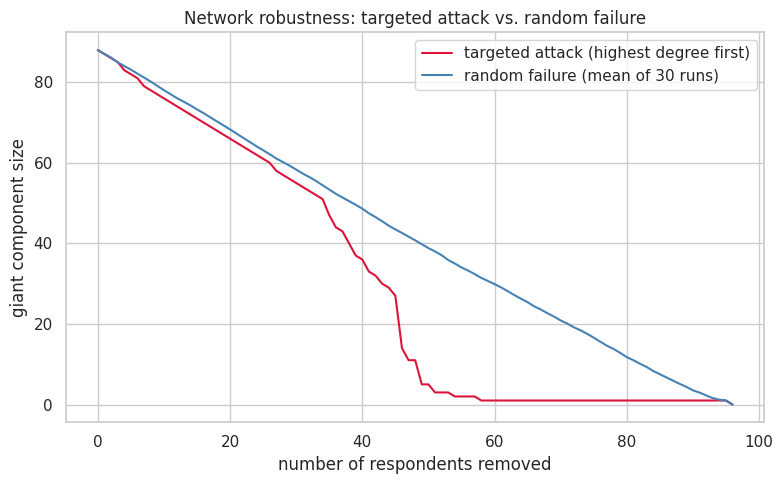

Respondents removed until giant component drops to half its original size: {'targeted': 35, 'random': 41}


In [16]:
def giant_component_curve(G, order):
    Gc = G.copy()
    sizes = [len(max(nx.connected_components(Gc), key=len))]
    for node in order:
        if node in Gc:
            Gc.remove_node(node)
        sizes.append(len(max(nx.connected_components(Gc), key=len)) if Gc.number_of_nodes() else 0)
    return sizes

# Targeted attack: always remove current highest-degree node (recomputed each step)
Gc = G_resp.copy()
targeted_order = []
while Gc.number_of_nodes() > 0:
    top = max(Gc.degree, key=lambda x: x[1])[0]
    targeted_order.append(top)
    Gc.remove_node(top)
targeted_curve = giant_component_curve(G_resp, targeted_order)

# Random failure: average over multiple random removal orders
rng = np.random.default_rng(0)
random_curves = []
nodes = list(G_resp.nodes)
for _ in range(30):
    order = rng.permutation(nodes).tolist()
    random_curves.append(giant_component_curve(G_resp, order))
random_curve_mean = np.mean(random_curves, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(targeted_curve))
ax.plot(x, targeted_curve, label="targeted attack (highest degree first)", color="crimson")
ax.plot(x, random_curve_mean, label="random failure (mean of 30 runs)", color="steelblue")
ax.set_xlabel("number of respondents removed")
ax.set_ylabel("giant component size")
ax.set_title("Network robustness: targeted attack vs. random failure")
ax.legend()
plt.tight_layout()
plt.show()

frac_removed_to_halve = {
    "targeted": next(i for i, v in enumerate(targeted_curve) if v <= G_resp.number_of_nodes() / 2),
    "random": next(i for i, v in enumerate(random_curve_mean) if v <= G_resp.number_of_nodes() / 2),
}
print(f"Respondents removed until giant component drops to half its original size: {frac_removed_to_halve}")

### A note on demographic overlay

We considered cross-checking communities against respondent demographics/behavior
(e.g. program, year, completion time), but `Survey_Results_UC.csv` only contains a
response ID and the 60 Likert answers — no such metadata exists in this dataset, so
that analysis isn't possible here. If the survey instrument is ever re-run with
demographic fields, this would be the natural next check.

## Summary

- Nodes = 96 respondents; edges = Pearson correlation across all 60 statements, kept
  above a threshold (r >= 0.4, justified by the percolation-style sweep in 3.1).
- The network is far from a single blob: density, giant-component size and clustering
  are reported in Section 3, with degree distribution, centrality (who holds the most
  "consensus" opinions) and Louvain communities (candidate opinion camps) in 3.2-3.4.
- Detected communities were cross-checked against mean per-category (T/E/S/V) scores
  to see whether opinion camps track a single topic or a broader alignment.
- The 5 respondents flagged as low-quality/straight-lined elsewhere show up as
  low-degree/near-isolated here, as expected, rather than as artificial hubs (3.5).

- **Robustness (Section 4):** community labels are reasonably stable across Louvain
  seeds and across nearby similarity thresholds (see ARI values in 4.1/4.2) — treat
  these as real, though not perfectly sharp, structure.
- **Pairwise distinctness (Section 5):** a full cross/within-similarity, cosine, and
  effect-size comparison between every pair of the four main communities, generalizing
  the earlier community-0-vs-3 analysis.
- **Method cross-check (Section 6):** Louvain communities were compared against
  asynchronous label propagation via Adjusted Rand Index as an independent sanity check.
- **Robustness to node removal (Section 7):** targeted (highest-degree-first) vs.
  random node removal shows how quickly the giant component fragments, i.e. whether a
  few respondents are structurally load-bearing for overall opinion cohesion.
- Demographic overlay was considered but skipped — the dataset has no fields beyond
  respondent ID and the 60 answers.